In [ ]:
##!pip install seaborn --upgrade
# ================== Imports ==================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================== 1️⃣ Charger tous les CSV ==================
files = {
    "CLAUDE_HAIKU": "LLM-classified-data/LLM - CLAUDE HAIKU 4.5.csv",
    "CLAUDE_SONNET": "LLM-classified-data/LLM - CLAUDE SONNET 4.5.csv",
    "GEMINI_FLASH": "LLM-classified-data/LLM - GEMINI 2.5 FLASH.csv",
    "GEMINI_PRO": "LLM-classified-data/LLM - GEMINI 2.5 PRO.csv",
    "GPT5_1": "LLM-classified-data/LLM - GPT 5.1.csv",
    "MISTRAL": "LLM-classified-data/LLM - mistral-small-latest.csv"
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

# ================== 2️⃣ Fusionner par tweet_id ==================
merged = dfs["CLAUDE_HAIKU"][["id","tweet"]].copy()
for name, df in dfs.items():
    merged[f"{name}_sentiment"] = df['sentiment']
    merged[f"{name}_theme"] = df['thème']
    merged[f"{name}_urgence"] = df['urgence']
    merged[f"{name}_confiance"] = df['confiance']

print(merged.head())



                    id                                              tweet  \
0  1343458257915031553  à parce que débit très instable, n nfree en fr...   
1  1485331097844129798  et vous ça se passe comment la fibre ? n c est...   
2  1694675653205860558  dans la lutte contre les installations sauvage...   
3  1695912123824546156  hello , et je crois que nous allons avoir proc...   
4  1711773973401235737  n nen 3 ans l équipe technique de free le boc ...   

  CLAUDE_HAIKU_sentiment CLAUDE_HAIKU_theme  CLAUDE_HAIKU_urgence  \
0                négatif     Débit Internet                     2   
1                négatif              Fibre                     2   
2                 neutre              Fibre                     0   
3                négatif              Fibre                     2   
4                négatif              Fibre                     3   

   CLAUDE_HAIKU_confiance CLAUDE_SONNET_sentiment CLAUDE_SONNET_theme  \
0                    0.75                 negatif

In [4]:
# ================== 3️⃣ Identifier les divergences ==================
# On crée des colonnes pour détecter divergences sentiment / thème / urgence
merged['sentiment_disagree'] = merged[[f"{name}_sentiment" for name in dfs]].nunique(axis=1) > 1
merged['theme_disagree'] = merged[[f"{name}_theme" for name in dfs]].nunique(axis=1) > 1
merged['urgence_disagree'] = merged[[f"{name}_urgence" for name in dfs]].nunique(axis=1) > 1

# Tweets le plus mal classifiés
mal_classifies = merged[merged['sentiment_disagree'] | merged['theme_disagree'] | merged['urgence_disagree']]
print(f"Nombre de tweets mal classifiés: {len(mal_classifies)}")
mal_classifies.head(10)

# ================== 4️⃣ Statistiques globales ==================
print("Tweets avec divergence par catégorie :")
print(mal_classifies[['sentiment_disagree','theme_disagree','urgence_disagree']].sum())



Nombre de tweets mal classifiés: 59
Tweets avec divergence par catégorie :
sentiment_disagree    54
theme_disagree        23
urgence_disagree      35
dtype: int64


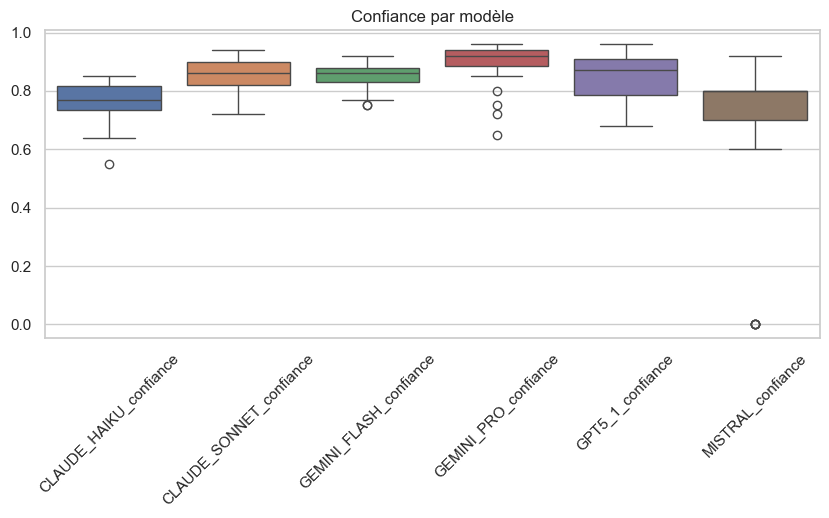

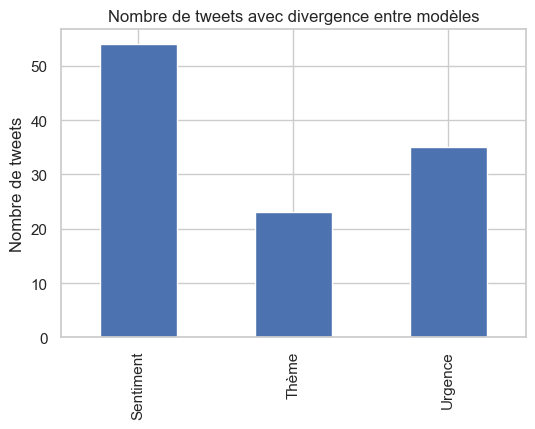

,id,tweet,mean_confiance,CLAUDE_HAIKU_sentiment,CLAUDE_SONNET_sentiment,GEMINI_FLASH_sentiment,GEMINI_PRO_sentiment,GPT5_1_sentiment,MISTRAL_sentiment,CLAUDE_HAIKU_theme,CLAUDE_SONNET_theme,GEMINI_FLASH_theme,GEMINI_PRO_theme,GPT5_1_theme,MISTRAL_theme
41,1814362356207759446,encore et encore,0.561667,négatif,negatif,negatif,negatif,negatif,neutre,Autre,Panne Internet,Panne Internet,Panne Internet,Panne Internet,Autre
30,1814296005510144260,l assistance free devient complètement aberran...,0.665000,négatif,negatif,negatif,negatif,negatif,neutre,Espace Client,Espace Client,Espace Client,Espace Client,Espace Client,Autre
3,1695912123824546156,"hello , et je crois que nous allons avoir proc...",0.706667,négatif,negatif,negatif,neutre,negatif,negatif,Fibre,Fibre,Fibre,Fibre,Fibre,Fibre
50,1814366416214048928,plus d internet depuis 45 mn ??,0.708333,négatif,neutre,negatif,negatif,negatif,neutre,Panne Internet,Panne Internet,Panne Internet,Panne Internet,Panne Internet,Autre
19,1814009656504885552,depuis le 23 06 je suis en attente d un rdv po...,0.716667,négatif,negatif,negatif,negatif,negatif,neutre,Fibre,Fibre,Fibre,Fibre,Fibre,Autre
36,1814353725663916160,idem ! est à cause de la panne mondiale ?,0.738333,neutre,neutre,neutre,neutre,neutre,neutre,Panne Internet,Panne Internet,Panne Internet,Panne Internet,Panne Internet,Panne Internet
18,1813886775799984228,c est normal des signalements pour pertes de s...,0.743333,négatif,negatif,negatif,negatif,negatif,neutre,Panne Internet,Panne Internet,Panne Internet,Panne Internet,Panne Internet,Autre
34,1814348631937311037,n ncoucou ! nje n arrive pas à me faire compre...,0.750000,neutre,neutre,neutre,neutre,neutre,neutre,Espace Client,Espace Client,Autre,Espace Client,Espace Client,Facturation
21,1814034736118927866,"allo,avez vous des nouvelles pour le réseau sv...",0.766667,neutre,neutre,neutre,neutre,neutre,neutre,Panne Internet,Panne Internet,Panne Internet,Panne Internet,Panne Internet,Panne Internet
49,1814366412007256112,bonjour free ! incidents en ce moment en fibre...,0.775000,neutre,neutre,neutre,neutre,neutre,neutre,Fibre,Panne Internet,Panne Internet,Panne Internet,Fibre,Fibre


In [6]:
# ================== 5️⃣ Visualisation ==================
sns.set(style="whitegrid")

# a) Distribution des désaccords par modèle (confiance moyenne)
plt.figure(figsize=(10,4))
conf_cols = [f"{name}_confiance" for name in dfs]
sns.boxplot(data=merged[conf_cols])
plt.title("Confiance par modèle")
plt.xticks(rotation=45)
plt.show()

# b) Histogramme des divergences sentiment / thème / urgence
div_df = pd.DataFrame({
    'Sentiment': mal_classifies['sentiment_disagree'].sum(),
    'Thème': mal_classifies['theme_disagree'].sum(),
    'Urgence': mal_classifies['urgence_disagree'].sum()
}, index=[0]).T

div_df.columns = ['Count']
div_df.plot(kind='bar', legend=False, figsize=(6,4))
plt.title("Nombre de tweets avec divergence entre modèles")
plt.ylabel("Nombre de tweets")
plt.show()

# ================== 6️⃣ Tweets les plus ambigus ==================
# On peut aussi trier par écart de confiance moyen faible
merged['mean_confiance'] = merged[[f"{name}_confiance" for name in dfs]].mean(axis=1)
ambigus = merged.sort_values('mean_confiance').head(20)
ambigus[['id','tweet','mean_confiance'] + [f"{name}_sentiment" for name in dfs] + [f"{name}_theme" for name in dfs]]
